# Full Swapping Experiment Results

Plotting only. Generate the CSV and NPZ files with `run_full_swapping_batch.py` first.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CANDIDATES = [
    Path('results/full_swapping_validation'),
    Path('example/entanglement_swapping_validation/results/full_swapping_validation'),
]
RESULTS_DIR = next((path for path in RESULTS_CANDIDATES if path.exists()), RESULTS_CANDIDATES[0])

counts = pd.read_csv(RESULTS_DIR / 'swapping_basis_counts_aggregated.csv')
summary = pd.read_csv(RESULTS_DIR / 'swapping_tomography_summary.csv')
matrices = np.load(RESULTS_DIR / 'swapping_density_matrices.npz')
summary

,bsm_state,expected_outer_state,fidelity,trace,minimum_eigenvalue,optimizer_success,optimizer_message
0,psi_minus,psi_minus,0.958219,1.0,0.003407,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,psi_plus,psi_plus,0.963020,1.0,0.002130,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


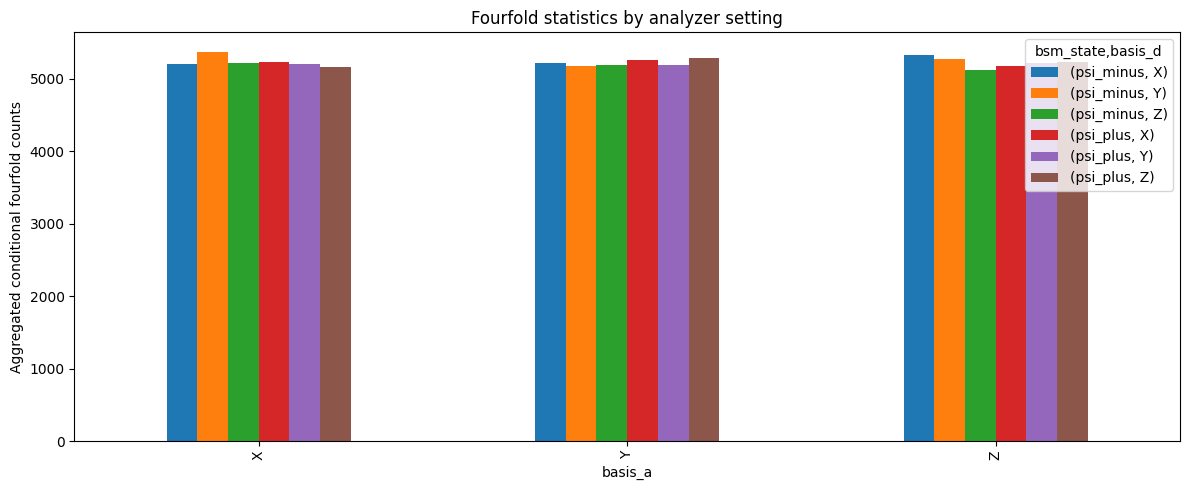

In [7]:
pivot = counts.pivot(index='basis_a', columns=['bsm_state', 'basis_d'], values='fourfold_count')
pivot.plot.bar(figsize=(12, 5))
plt.ylabel('Aggregated conditional fourfold counts')
plt.title('Fourfold statistics by analyzer setting')
plt.tight_layout()

c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


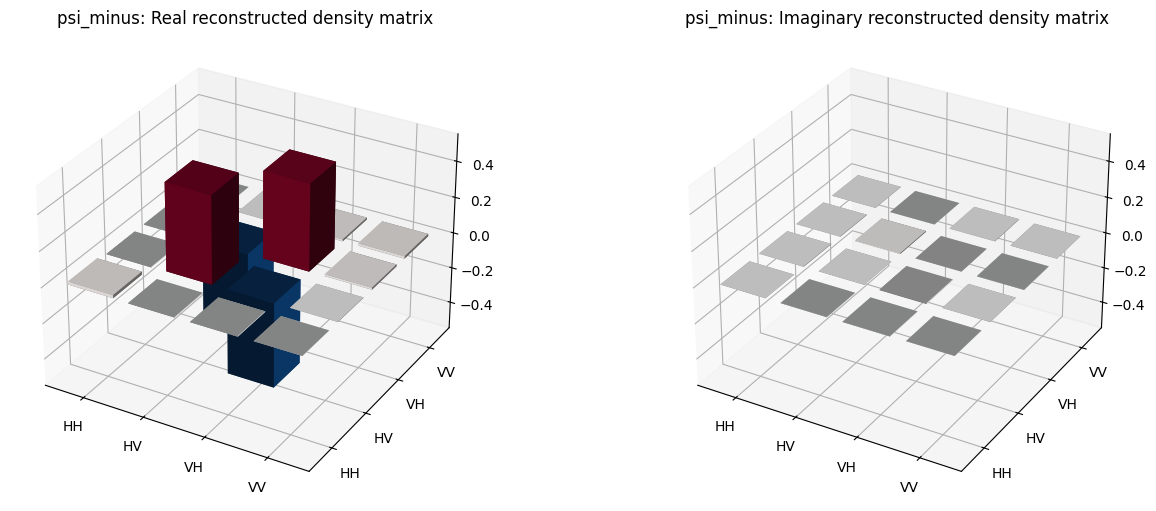

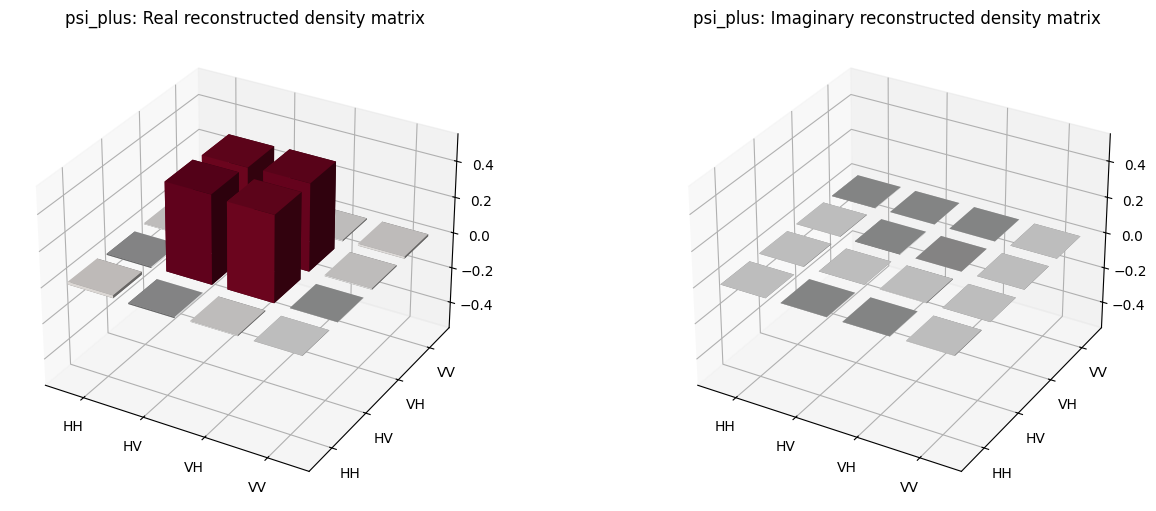

In [8]:
labels = ['HH', 'HV', 'VH', 'VV']
x, y = np.meshgrid(np.arange(4), np.arange(4))
for bsm_state in ('psi_minus', 'psi_plus'):
    rho = matrices[f'{bsm_state}_real'] + 1j * matrices[f'{bsm_state}_imag']
    fig = plt.figure(figsize=(13, 5), constrained_layout=True)
    for position, (matrix, title) in enumerate(((rho.real, 'Real'), (rho.imag, 'Imaginary')), 1):
        ax = fig.add_subplot(1, 2, position, projection='3d')
        values = matrix.ravel()
        ax.bar3d(x.ravel(), y.ravel(), np.zeros(16), .75, .75, values,
                 color=plt.cm.RdBu_r((values + .5).clip(0, 1)))
        ax.set_xticks(np.arange(4) + .375, labels)
        ax.set_yticks(np.arange(4) + .375, labels)
        ax.set_zlim(-.55, .55)
        ax.set_title(f'{bsm_state}: {title} reconstructed density matrix')